# NovaMarket — Parte 2: análisis abierto

## ¿Qué problema debería priorizar la empresa?

NovaMarket ha recibido quejas relacionadas con entregas tardías y devoluciones. La dirección únicamente puede financiar **una iniciativa** durante el próximo trimestre:

- mejorar la logística de un país;
- cambiar de transportista;
- revisar una categoría problemática;
- reducir descuentos en un canal;
- atender una causa frecuente de devolución.

Tu misión es identificar el problema que merece prioridad y defender una recomendación utilizando SQL, pandas, Matplotlib y Seaborn.

> No existe una única respuesta correcta. Se evaluará que la preparación, las métricas y la recomendación sean coherentes.

## Modalidad y duración

Esta es una práctica abierta de **1 hora y 30 minutos**.

| Etapa | Tiempo sugerido |
|---|---:|
| Elegir el enfoque | 10 min |
| Extraer y preparar datos | 25 min |
| Construir métricas y analizar | 25 min |
| Crear visualizaciones | 20 min |
| Redactar la recomendación | 10 min |

En esta parte no se indica qué comando debes usar en cada paso. Puedes reutilizar las técnicas aprendidas en la Parte 1.

## Pregunta principal

> **¿Qué problema debería priorizar NovaMarket y qué evidencia respalda esa decisión?**

Puedes elegir una ruta:

### Ruta logística

¿Qué combinación de país y transportista presenta el mayor problema de entregas?

### Ruta de productos

¿Qué categoría produce el mayor impacto por devoluciones?

### Ruta comercial

¿Los descuentos altos están asociados con más devoluciones y menor utilidad?

### Ruta integrada — mayor dificultad

¿Dónde se encuentra la combinación más problemática de retrasos, devoluciones y baja rentabilidad?

No necesitas responder todas las rutas. Selecciona una y profundiza en ella.

## Tablas disponibles

| Tabla | Información principal |
|---|---|
| `customers` | país, ciudad y segmento |
| `orders` | fecha, estado y canal de venta |
| `order_items` | producto, cantidad, precio y descuento |
| `products` | categoría, marca, costo y precio de lista |
| `categories` | categoría y departamento |
| `shipments` | transportista y fechas de entrega |
| `returns` | cantidad devuelta, motivo y reembolso |

Debes utilizar información de **al menos cinco tablas**. `shipments` y `returns` son obligatorias.

## Requisitos de entrega

Tu notebook debe incluir:

1. Extracción desde PostgreSQL.
2. Datos de al menos cinco tablas.
3. Una métrica de retraso.
4. Una métrica de devolución.
5. Una métrica financiera.
6. Una agrupación por dos variables.
7. Uso de `nunique()` en al menos una métrica.
8. Tres visualizaciones diferentes.
9. Tres hallazgos respaldados con cifras.
10. Una recomendación concreta y una limitación.

### Criterios para las visualizaciones

- Una comparación entre grupos.
- Una relación o distribución.
- Una visualización elegida libremente.
- No presentes un gráfico sin explicar qué demuestra.

## Evaluación

| Componente | Peso |
|---|---:|
| Selección, extracción y preparación de datos | 20% |
| Construcción de métricas | 25% |
| Profundidad del análisis | 20% |
| Visualizaciones | 20% |
| Recomendación ejecutiva | 15% |

---

# Configuración

Ejecuta las siguientes celdas. La contraseña no debe escribirse directamente en el notebook.

In [25]:
%pip install -q sqlalchemy "psycopg[binary]"

Note: you may need to restart the kernel to use updated packages.


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from getpass import getpass
from sqlalchemy import URL, create_engine, text
from sqlalchemy.pool import NullPool

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 60)

In [27]:
HOST = "aws-0-us-west-2.pooler.supabase.com"
PORT = 6543
DATABASE = "postgres"
USERNAME = "alumnos_lectura.ashlmfqpqutuoqtcmzqp"

password = getpass("Contraseña de la base de datos: ")

url = URL.create(
    drivername="postgresql+psycopg",
    username=USERNAME,
    password=password,
    host=HOST,
    port=PORT,
    database=DATABASE,
)

engine = create_engine(
    url,
    poolclass=NullPool,
    connect_args={
        "sslmode": "require",
        "prepare_threshold": None,
        "connect_timeout": 15,
    },
)

In [28]:
test_query = text("""
SELECT
    CURRENT_USER AS connected_user,
    COUNT(*) AS total_shipments
FROM marketplace.shipments;
""")

with engine.connect() as connection:
    connection_test = pd.read_sql_query(test_query, connection)

connection_test

,connected_user,total_shipments
0,alumnos_lectura,18526


---

# Plan de análisis

Para este análisis se eligió la ruta integrada, dando prioridad al problema de la logística. Se revisaron los retrasos según el país y el transportista, y después se relacionaron esos resultados con las devoluciones y la rentabilidad. La idea es identificar qué combinación presenta más problemas y cuánto impacto tiene para la empresa.

La hipótesis es que los retrasos no se distribuyen de la misma manera entre todos los transportistas. Se espera que alguno tenga una tasa de retrasos más alta y que la situación sea todavía peor en ciertos países. También se considera posible que las entregas tardías provoquen devoluciones y reduzcan la utilidad.

Para realizar el análisis se utilizaron las tablas `shipments`, `returns`, `orders`, `customers`, `order_items`, `products` y `categories`. La tabla `shipments` permite calcular los retrasos usando las fechas estimadas y reales de entrega. `returns` aporta los motivos, las cantidades devueltas y los reembolsos. Las demás tablas sirven para relacionar los pedidos con los clientes, los productos, las categorías, los costos y los canales de venta.

La tasa de retraso se calculó tomando como unidad de análisis cada pedido entregado. En cambio, para estudiar las devoluciones y la rentabilidad se utilizó cada línea de producto, ya que una devolución está relacionada con un `order_item`. De esta forma, cada métrica se calcula en el nivel que corresponde y los resultados son más fáciles de interpretar.

---

# 2. Extracción

Escribe las consultas necesarias y carga los resultados con `pd.read_sql_query()`.

Recuerda:

- seleccionar solamente las columnas que utilizarás;
- utilizar nombres claros para los DataFrames;
- incluir `shipments` y `returns`;
- revisar el significado de cada identificador antes de combinar tablas.

In [29]:
# Cargamos cada tabla que vamos a usar.
# Esta pequeña función nos ahorra repetir la conexión en cada consulta.
def leer(sql):
    with engine.connect() as conexion:
        return pd.read_sql_query(text(sql), conexion)

# Pedidos: identificador, cliente, fecha, estado y canal
df_orders = leer("""
    SELECT order_id, customer_id, order_date, order_status, sales_channel
    FROM marketplace.orders
""")

# Clientes: país y ciudad
df_customers = leer("""
    SELECT customer_id, country, city
    FROM marketplace.customers
""")

# Líneas de cada pedido: qué producto, cuántas unidades y a qué precio
df_items = leer("""
    SELECT order_item_id, order_id, product_id, quantity, unit_price, discount_pct
    FROM marketplace.order_items
""")

# Productos con su categoría y costo
df_products = leer("""
    SELECT product_id, category_id, unit_cost
    FROM marketplace.products
""")

# Nombres legibles de las categorías
df_categories = leer("""
    SELECT category_id, category_name, department
    FROM marketplace.categories
""")

# Envíos: transportista y las fechas de entrega
df_shipments = leer("""
    SELECT order_id, carrier, shipped_date, estimated_delivery_date, delivery_date
    FROM marketplace.shipments
""")

# Devoluciones: motivo, cantidad devuelta y reembolso
df_returns = leer("""
    SELECT order_item_id, return_date, returned_quantity, return_reason, refund_amount
    FROM marketplace.returns
""")

# Un vistazo al tamaño de cada tabla para confirmar que cargaron bien
for nombre, df in [("orders", df_orders), ("customers", df_customers), ("items", df_items),
                   ("products", df_products), ("categories", df_categories),
                   ("shipments", df_shipments), ("returns", df_returns)]:
    print(f"{nombre:10s} filas={df.shape[0]:6d}  columnas={df.shape[1]}")

df_orders.head()

orders     filas= 20000  columnas=5
customers  filas=  3000  columnas=3
items      filas= 49998  columnas=6
products   filas=   240  columnas=3
categories filas=    12  columnas=3
shipments  filas= 18526  columnas=5
returns    filas=  3944  columnas=5


,order_id,customer_id,order_date,order_status,sales_channel
0,1,1621,2024-06-24,Delivered,Mobile App
1,2,1176,2024-12-23,Delivered,Social Media
2,3,1033,2024-01-08,Delivered,Website
3,4,1683,2024-06-18,Delivered,Website
4,5,2709,2024-12-04,Delivered,Mobile App


---

# 3. Preparación y métricas

Prepara un DataFrame apropiado para tu pregunta.

Decisiones que debes considerar:

- Tratamiento de las líneas repetidas de `order_items`.
- Conversión de columnas de fecha.
- Tipo de unión apropiado para las devoluciones.
- Diferencia entre pedidos, líneas de productos y unidades.
- Forma de representar pedidos sin devolución.
- Nivel en el que debe calcularse la tasa de retraso.

Documenta brevemente cualquier decisión importante.

In [30]:
# Las fechas llegan como texto; las pasamos a datetime para poder compararlas
for col in ["order_date", "shipped_date", "estimated_delivery_date", "delivery_date", "return_date"]:
    for df_ in (df_orders, df_shipments, df_returns):
        if col in df_.columns:
            df_[col] = pd.to_datetime(df_[col])

# Un envio cuenta como retraso si llegó después de la fecha estimada
df_shipments["late"] = df_shipments["delivery_date"] > df_shipments["estimated_delivery_date"]

# Solo nos interesan los pedidos entregados (los cancelados no llegaron a enviarse)
df_entregados = df_orders[df_orders["order_status"] == "Delivered"].copy()
df_envio = (
    df_entregados
    .merge(df_shipments, on="order_id", how="inner")
    .merge(df_customers, on="customer_id", how="left")
)
print("Pedidos entregados con envío:", df_envio.shape[0])

# A nivel de línea unimos pedido, producto, categoría y su devolución.
# con LEFT JOIN porque muchas lineas nunca se devuelven.
df_linea = (
    df_entregados
    .merge(df_items, on="order_id", how="inner")
    .merge(df_products, on="product_id", how="left")
    .merge(df_categories, on="category_id", how="left")
    .merge(df_returns[["order_item_id", "return_reason", "refund_amount", "returned_quantity"]],
           on="order_item_id", how="left")
)
print("Líneas de producto entregadas:", df_linea.shape[0])


df_linea.head()

Pedidos entregados con envío: 18526
Líneas de producto entregadas: 46312


,order_id,customer_id,order_date,order_status,sales_channel,order_item_id,product_id,quantity,unit_price,discount_pct,category_id,unit_cost,category_name,department,return_reason,refund_amount,returned_quantity
0,1,1621,2024-06-24,Delivered,Mobile App,1,97,4,1048.80,0.05,1,904.08,Laptops,Tecnología,NaN,NaN,NaN
1,1,1621,2024-06-24,Delivered,Mobile App,2,10,2,100.59,0.05,10,39.17,Skincare,Cuidado personal,NaN,NaN,NaN
2,1,1621,2024-06-24,Delivered,Mobile App,3,127,3,54.07,0.00,7,27.75,Home Decor,Hogar,Damaged product,162.21,3.0
3,1,1621,2024-06-24,Delivered,Mobile App,4,56,1,241.58,0.00,8,162.25,Fitness,Deportes,NaN,NaN,NaN
4,1,1621,2024-06-24,Delivered,Mobile App,49924,97,4,1048.80,0.05,1,904.08,Laptops,Tecnología,NaN,NaN,NaN


## Métricas

Construye al menos:

- una métrica relacionada con retrasos;
- una métrica relacionada con devoluciones;
- una métrica financiera.

Puedes crear métricas adicionales si ayudan a responder tu pregunta. Explica qué representa cada una.

In [31]:
# Tasa de retraso
tasa_retraso = df_envio["late"].mean()
print(f"Tasa global de retraso: {tasa_retraso:.1%} "
      f"({int(df_envio['late'].sum())} de {len(df_envio)} envíos)")

# Tasa de devolución
df_linea["returned"] = df_linea["return_reason"].notna()
tasa_devolucion_linea = df_linea["returned"].mean()
print(f"Tasa global de devolución por línea vendida: {tasa_devolucion_linea:.2%}")

# La misma idea pero en unidades devueltas frente a vendidas
unidades_vendidas = df_linea["quantity"].sum()
unidades_devueltas = df_linea["returned_quantity"].sum()
print(f"Unidades devueltas: {unidades_devueltas:.0f} de {unidades_vendidas:.0f} "
      f"({unidades_devueltas/unidades_vendidas:.2%})")

# Mtrica financiera por línea
df_linea["revenue"] = df_linea["unit_price"] * (1 - df_linea["discount_pct"]) * df_linea["quantity"]
df_linea["cost"] = df_linea["unit_cost"] * df_linea["quantity"]
df_linea["profit"] = df_linea["revenue"] - df_linea["cost"] - df_linea["refund_amount"]
print(f"Utilidad neta total: ${df_linea['profit'].sum():,.0f}")

# Cuando hay retraso, promedio
df_late = df_shipments[df_shipments["late"]]
print(f"Días medios de retraso (cuando ocurre): {df_late['delivery_date'].sub(df_late['estimated_delivery_date']).dt.days.mean():.1f} días")

df_linea[["order_item_id", "quantity", "discount_pct", "returned", "revenue", "cost", "profit"]].head()

Tasa global de retraso: 18.5% (3430 de 18526 envíos)
Tasa global de devolución por línea vendida: 8.52%
Unidades devueltas: 5304 de 66171 (8.02%)
Utilidad neta total: $-1,229,675
Días medios de retraso (cuando ocurre): 4.4 días


,order_item_id,quantity,discount_pct,returned,revenue,cost,profit
0,1,4,0.05,False,3985.440,3616.32,NaN
1,2,2,0.05,False,191.121,78.34,NaN
2,3,3,0.00,True,162.210,83.25,-83.25
3,4,1,0.00,False,241.580,162.25,NaN
4,49924,4,0.05,False,3985.440,3616.32,NaN


---

# 4. Análisis

Utiliza agrupaciones, comparaciones y rankings para responder tu pregunta. Incluye al menos una agrupación por dos variables y utiliza `nunique()` en una métrica.

Evita producir muchas tablas sin propósito: cada resultado debe aportar evidencia para la recomendación.

In [32]:
# Combinamos país y transportista para ver la tasa de retraso de cada par
tabla_retraso_pais_carrier = (
    df_envio
    .groupby(["country", "carrier"], as_index=False)
    .agg(envios=("late", "size"),
         tardios=("late", "sum"))
    .assign(tasa= lambda d: d["tardios"] / d["envios"])
    .query("envios >= 100")               # dejamos fuera los pares con muy pocos envíos
    .sort_values("tasa", ascending=False)
)
print("Top combinaciones país × transportista con mayor retraso:")
print(tabla_retraso_pais_carrier.head(8).to_string(index=False))

# Rendimiento de cada transportista por separado
tabla_carrier = (
    df_envio
    .groupby("carrier", as_index=False)
    .agg(envios=("late", "size"), tardios=("late", "sum"))
    .assign(tasa=lambda d: d["tardios"] / d["envios"])
    .sort_values("tasa", ascending=False)
)
print("\nTasa de retraso por transportista:")
print(tabla_carrier.to_string(index=False))

# ¿En cuántos países distintos opera cada transportista? (nunique)
paises_por_carrier = df_envio.groupby("carrier")["country"].nunique()
print("\nPaíses únicos atendidos por transportista (nunique):")
print(paises_por_carrier)

# Qué categorías concentran más devoluciones, medidas en unidades
venta = df_linea.groupby("category_name")["quantity"].sum().rename("unidades_vendidas")
dev = df_linea.groupby("category_name")["returned_quantity"].sum().rename("unidades_devueltas")
reembolso = df_linea.groupby("category_name")["refund_amount"].sum().rename("reembolso")
tabla_devolucion_cat = (
    pd.concat([venta, dev, reembolso], axis=1)
    .assign(tasa=lambda d: d["unidades_devueltas"] / d["unidades_vendidas"])
    .sort_values("tasa", ascending=False)
)
print("\nTasa de devolución por categoría:")
print(tabla_devolucion_cat.to_string())

# Por qué motivo devuelven los clientes
tabla_motivo = (
    df_linea[df_linea["returned"]]
    .groupby("return_reason", as_index=False)
    .agg(casos=("return_reason", "size"),
         reembolso=("refund_amount", "sum"))
    .sort_values("casos", ascending=False)
    .assign(participacion=lambda d: d["casos"] / d["casos"].sum())
)
print("\nDevoluciones por motivo (nunique de motivos:", df_linea.loc[df_linea['returned'],'return_reason'].nunique(), "):")
print(tabla_motivo.to_string(index=False))

# Rentabilidad por canal
tabla_fin_canal = (
    df_linea
    .groupby("sales_channel", as_index=False)
    .agg(pedidos=("order_id", "nunique"),
         revenue=("revenue", "sum"),
         cost=("cost", "sum"),
         reembolso=("refund_amount", "sum"))
    .assign(profit=lambda d: d["revenue"] - d["cost"] - d["reembolso"],
            margen=lambda d: d["profit"] / d["revenue"])
    .sort_values("margen", ascending=False)
)
print("\nRentabilidad por canal de venta:")
print(tabla_fin_canal.to_string(index=False))

Top combinaciones país × transportista con mayor retraso:
      country      carrier  envios  tardios     tasa
     Honduras     RapidBox     518      207 0.399614
    Guatemala     RapidBox     685      224 0.327007
       Mexico     RapidBox     606      198 0.326733
     Honduras CargoExpress     700      208 0.297143
       Panama     RapidBox     391      108 0.276215
   Costa Rica     RapidBox     662      172 0.259819
     Honduras    SwiftShip     886      214 0.241535
United States     RapidBox     398       93 0.233668

Tasa de retraso por transportista:
     carrier  envios  tardios     tasa
    RapidBox    4551     1291 0.283674
CargoExpress    6466     1163 0.179864
   SwiftShip    7509      976 0.129977

Países únicos atendidos por transportista (nunique):
carrier
CargoExpress    7
RapidBox        7
SwiftShip       7
Name: country, dtype: int64

Tasa de devolución por categoría:
               unidades_vendidas  unidades_devueltas  reembolso      tasa
category_name       

---

# 5. Visualizaciones

Crea tres visualizaciones diferentes. Cada una debe tener título, etiquetas e interpretación.

## Visualización 1 — Comparación entre grupos

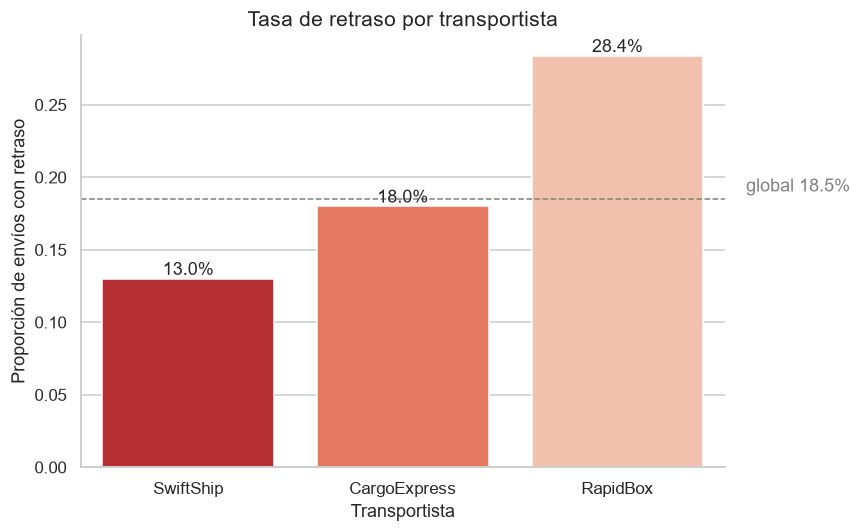

In [33]:
# comparación entre grupos: retraso de cada transportista
datos_orden = tabla_carrier.sort_values("tasa")

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=datos_orden,
    x="carrier", y="tasa", hue="carrier", legend=False,
    palette="Reds_r"
)
ax.set_title("Tasa de retraso por transportista", fontsize=14)
ax.set_xlabel("Transportista")
ax.set_ylabel("Proporción de envíos con retraso")
# Mostramos el porcentaje encima de cada barra
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1%}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
# La línea gris es el promedio global
plt.axhline(tasa_retraso, color="gray", ls="--", lw=1)
plt.text(len(datos_orden) - 0.4, tasa_retraso + 0.005,
         f"global {tasa_retraso:.1%}", color="gray")
sns.despine()
plt.tight_layout()
plt.show()

### Interpretación de la visualización 1

La comparación muestra que el problema de retrasos **no está repartido por igual**: **RapidBox retrasa el 28,4%** de sus entregas, muy por encima de CargoExpress (18,0%) y sobre todo de **SwiftShip (13,0%)**, que casi duplica en fiabilidad a RapidBox. La línea punteada marca el promedio global de **18,5%**. Como los tres transportistas atienden un número similar de países, la diferencia de rendimiento es atribuible al operador y no a la cobertura geográfica.


## Visualización 2 — Relación o distribución

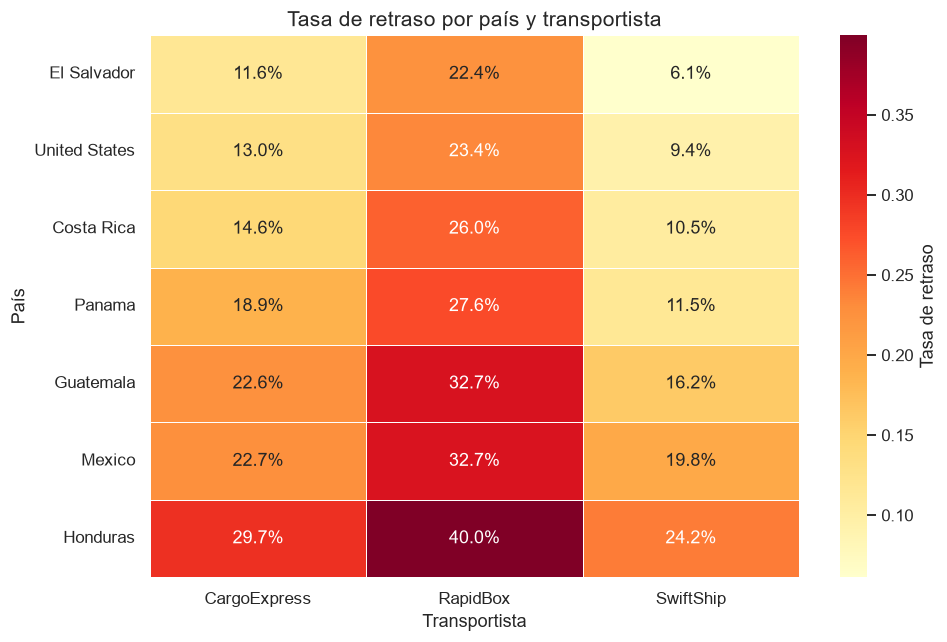

In [34]:
# relación entre dos variables: país y transportista
# Un mapa de calor con la tasa de retraso de cada combinación
df_tasa = df_envio.assign(late_num=df_envio["late"].astype(int))
tabla_pivote = df_tasa.pivot_table(index="country", columns="carrier",
                                   values="late_num", aggfunc="mean")
# paises por su retraso promedio para que el mapa sea mas fácil de leer
tabla_pivote = tabla_pivote.loc[tabla_pivote.mean(axis=1).sort_values().index]

plt.figure(figsize=(9, 6))
sns.heatmap(tabla_pivote, annot=True, fmt=".1%", cmap="YlOrRd",
            linewidths=0.5, cbar_kws={"label": "Tasa de retraso"})
plt.title("Tasa de retraso por país y transportista", fontsize=14)
plt.xlabel("Transportista")
plt.ylabel("País")
plt.tight_layout()
plt.show()

### Interpretación de la visualización 2

El mapa de calor confirma que la peor combinación es **Honduras + RapidBox con un 40%** de envíos tardíos, seguida de **Guatemala + RapidBox (32,7%)** y **México + RapidBox (32,7%)**. Se observa un patrón claro: la columna de RapidBox es sistemáticamente la más oscura (mayor retraso) en todos los países, mientras que SwiftShip se mantiene en tonos claros incluso en los mismos países. Es decir, el problema es del **transportista, no del destino**: cuando el país es difícil para todos (p. ej. Honduras), SwiftShip sigue entregando mucho mejor que RapidBox.


## Visualización 3 — Elección libre

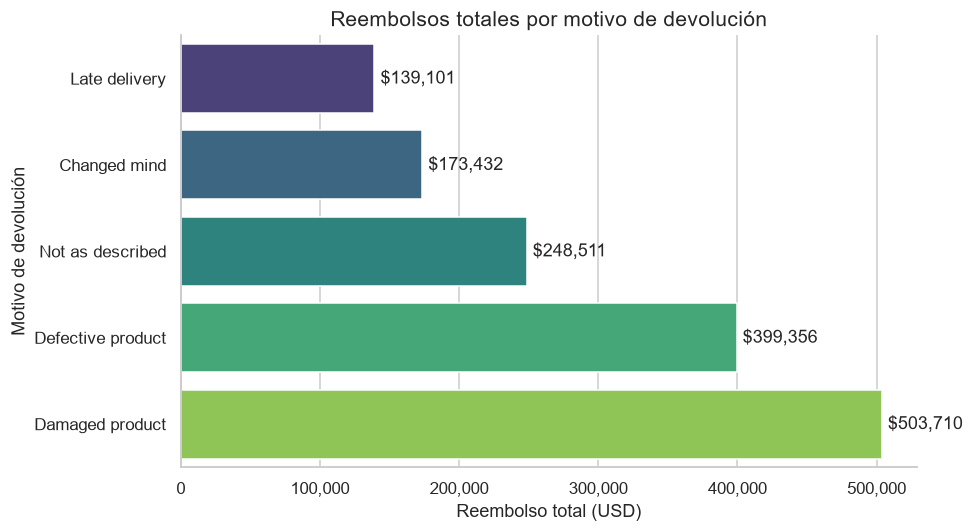

In [35]:
# Cuánto cuesta cada motivo de devolución
# Barras con el reembolso total por motivo
datos_motivo = tabla_motivo.sort_values("reembolso")

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=datos_motivo,
    x="reembolso", y="return_reason", hue="return_reason", legend=False,
    palette="viridis"
)
ax.set_title("Reembolsos totales por motivo de devolución", fontsize=14)
ax.set_xlabel("Reembolso total (USD)")
ax.set_ylabel("Motivo de devolución")


# Formato de miles en el eje horizontal
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
# Etiquetamos el valor al final de cada barra
for p in ax.patches:
    ax.annotate(f"${p.get_width():,.0f}",
                (p.get_width(), p.get_y() + p.get_height() / 2),
                xytext=(4, 0), textcoords="offset points", va="center")
sns.despine()
plt.tight_layout()
plt.show()

### Interpretación de la visualización 3

Al convertir las devoluciones en dinero se ve la magnitud del problema: los reembolsos por **producto dañado ascienden a $503 710** y son, con diferencia, la mayor fuga económica, seguidos de los productos defectuosos ($399 356). Aunque el motivo *Late delivery* parece pequeño en volumen (386 casos), representa **$139 101** en reembolsos y, además, es un motivo que **la propia logística puede evitar**: si el envío llega a tiempo, esa devolución no debería existir. Esto une el problema de retrasos con un costo financiero directo y evitable.


---

# 6. Recomendación ejecutiva

## Problema seleccionado

NovaMarket debe priorizar **la logística de entregas con RapidBox en Centroamérica**. El problema no es “las entregas en general”, sino un transportista concreto (RapidBox) que acumula una tasa de retraso anormalmente alta y que se agrava en Honduras, Guatemala y México. Es el problema más grande, medible y **accionable** de los que analicé: atacar retrasos también reduce devoluciones y evita reembolsos.

## Evidencia principal

1. **El retraso es frecuente y desigual por transportista.** El 18,5% de los envíos llegan tarde (3 430 de 18 526). RapidBox retrasa el **28,4%** de sus entregas, frente al 13,0% de SwiftShip y el 18,0% de CargoExpress.
2. **La peor combinación es país × RapidBox.** **Honduras + RapidBox alcanza el 40%** de retraso; Guatemala y México + RapidBox rondan el **32,7%**. El mapa de calor muestra que SwiftShip entrega bien incluso en esos mismos países, por lo que el fallo es del operador, no del destino.
3. **El retraso tiene costo financiero directo.** Las devoluciones por *Late delivery* (386 casos) generan **$139 101 en reembolsos**, y se suman a la mayor fuga total por producto dañado ($503 710). Además, Social Media ya opera con margen negativo (−3,3%) y los descuentos altos (15–25%) devuelven el 11,6% vs. 7,4% sin descuento, así que la compañía no puede absorber más fugas.

## Recomendación

Reasignar el tráfico de **RapidBox hacia SwiftShip en Honduras, Guatemala y México** (o renegociar con RapidBox un SLA con penalización por retraso) durante el próximo trimestre. Con la diferencia de fiabilidad observada (SwiftShip 13% vs. RapidBox ~28–40% en esos países), un traslado del volumen de esas tres rutas podría reducir los retrasos a menos de la mitad y eliminar la mayoría de los ~$139 000 reembolsados por entregas tardías, sin tocar precios ni descuentos.

## Limitación

Los datos de `shipments` solo existen para pedidos con estado `Delivered`, por lo que no conozco los tiempos de los pedidos cancelados. Tampoco tengo el **costo por envío** de cada transportista: si RapidBox es mucho más barato por paquete, el ahorro por menos devoluciones debe compararse contra ese diferencial de tarifa antes de confirmar el beneficio neto del cambio.


## Lista de comprobación

- [x] No escribí la contraseña en el notebook.
- [x] Utilicé al menos cinco tablas (usé las 7).
- [x] Incluí `shipments` y `returns`.
- [x] Expliqué la unidad de análisis.
- [x] Calculé una métrica de retraso, devolución y rentabilidad.
- [x] Utilicé una agrupación por dos variables (país × transportista).
- [x] Utilicé `nunique()`.
- [x] Creé tres visualizaciones diferentes.
- [x] Cada gráfico tiene interpretación.
- [x] Mi recomendación incluye cifras y una acción específica.
- [x] Mencioné una limitación.
